# Classification Model — Bank Marketing

**Task:** Predict whether a customer will subscribe to a term deposit (`yes`/`no`) based on demographic + interaction features.

**Dataset:** UCI Bank Marketing (45,211 rows, 16 features). Highly imbalanced — ~88% no, ~12% yes.

**Model:** Logistic Regression with `class_weight='balanced'` to compensate for class imbalance.

**Pipeline:** `ColumnTransformer(StandardScaler on numerics, OneHotEncoder on categoricals)` → `LogisticRegression`.

**Deployed to:** AWS SageMaker (`ml.t2.medium`, sklearn 1.2-1 framework container).

Output: `model.joblib` + `metrics.json` saved to `ml/classification/`.

## 1. Imports and setup

In [1]:
import json
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix,
    f1_score, precision_score, recall_score,
)
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

RANDOM_STATE = 42
OUT_DIR = Path('../ml/classification')
OUT_DIR.mkdir(parents=True, exist_ok=True)
DATA_PATH = OUT_DIR / 'data' / 'bank.csv'

## 2. Load the dataset

The UCI Bank Marketing dataset is shipped as `bank-full.csv` with semicolon delimiter. We saved a renamed copy at `ml/classification/data/bank.csv`.

In [2]:
df = pd.read_csv(DATA_PATH, sep=';')
print(f'Shape: {df.shape}')
df.head()

Shape: (45211, 17)


,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,no
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown,no
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,-1,0,unknown,no
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,-1,0,unknown,no


## 3. Exploratory Data Analysis

In [3]:
df.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
age,45211.0,NaN,NaN,NaN,40.93621,10.618762,18.0,33.0,39.0,48.0,95.0
job,45211,12,blue-collar,9732,NaN,NaN,NaN,NaN,NaN,NaN,NaN
marital,45211,3,married,27214,NaN,NaN,NaN,NaN,NaN,NaN,NaN
education,45211,4,secondary,23202,NaN,NaN,NaN,NaN,NaN,NaN,NaN
default,45211,2,no,44396,NaN,NaN,NaN,NaN,NaN,NaN,NaN
balance,45211.0,NaN,NaN,NaN,1362.272058,3044.765829,-8019.0,72.0,448.0,1428.0,102127.0
housing,45211,2,yes,25130,NaN,NaN,NaN,NaN,NaN,NaN,NaN
loan,45211,2,no,37967,NaN,NaN,NaN,NaN,NaN,NaN,NaN
contact,45211,3,cellular,29285,NaN,NaN,NaN,NaN,NaN,NaN,NaN
day,45211.0,NaN,NaN,NaN,15.806419,8.322476,1.0,8.0,16.0,21.0,31.0


In [4]:
print('Missing values per column:')
print(df.isna().sum())

Missing values per column:
age          0
job          0
marital      0
education    0
default      0
balance      0
housing      0
loan         0
contact      0
day          0
month        0
duration     0
campaign     0
pdays        0
previous     0
poutcome     0
y            0
dtype: int64


Class balance:
y
no     0.883015
yes    0.116985
Name: proportion, dtype: float64


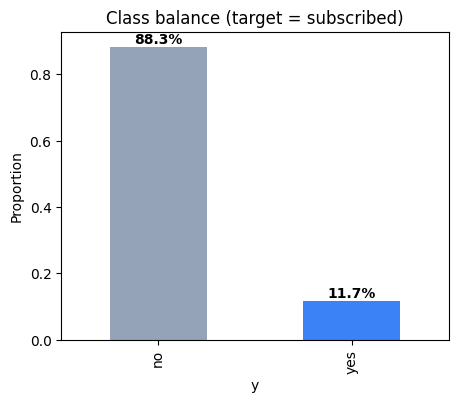

In [5]:
# Class balance
balance = df['y'].value_counts(normalize=True)
print('Class balance:')
print(balance)

fig, ax = plt.subplots(figsize=(5, 4))
balance.plot(kind='bar', color=['#94a3b8', '#3b82f6'], ax=ax)
ax.set_title('Class balance (target = subscribed)')
ax.set_ylabel('Proportion')
for i, v in enumerate(balance.values):
    ax.text(i, v + 0.01, f'{v:.1%}', ha='center', fontweight='bold')
plt.show()

**Severe class imbalance:** ~88% no, ~12% yes. Without correction the model would be biased toward predicting 'no' for everything.

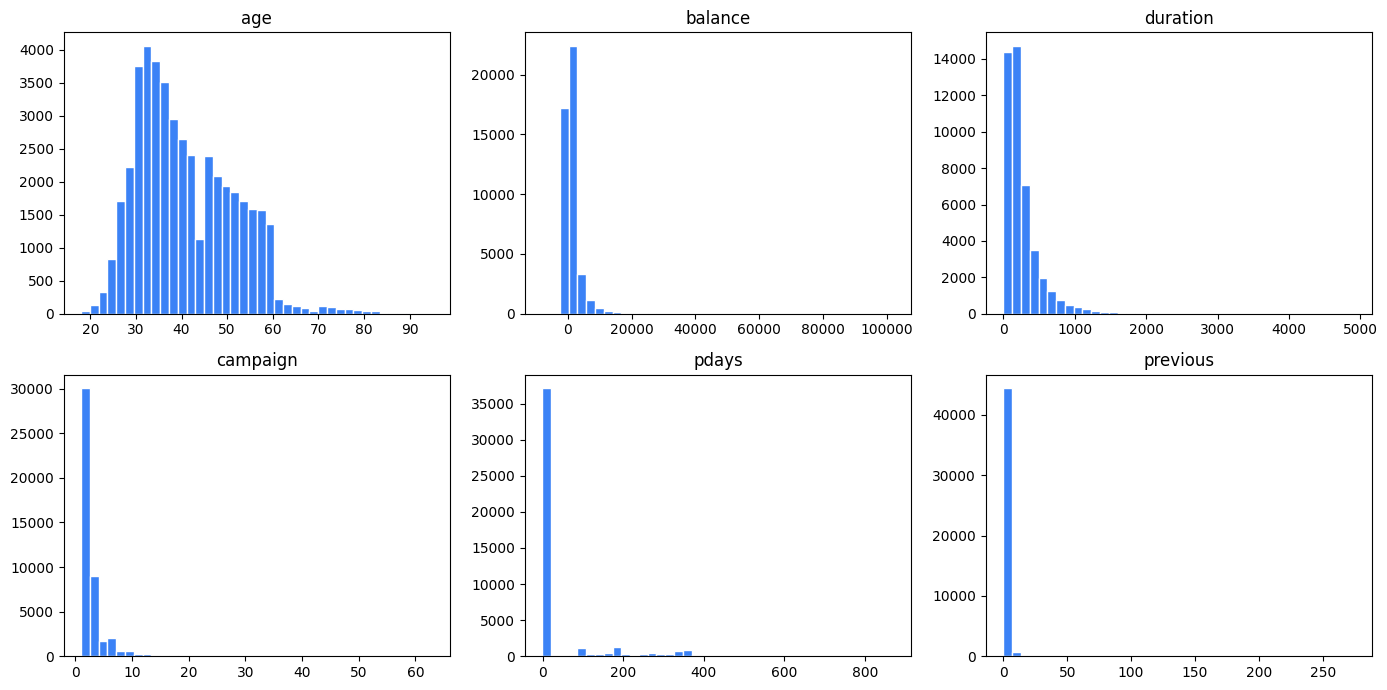

In [6]:
# Numeric column distributions
numeric_cols = ['age', 'balance', 'duration', 'campaign', 'pdays', 'previous']
fig, axes = plt.subplots(2, 3, figsize=(14, 7))
for ax, col in zip(axes.flat, numeric_cols):
    ax.hist(df[col], bins=40, color='#3b82f6', edgecolor='white')
    ax.set_title(col)
plt.tight_layout()
plt.show()

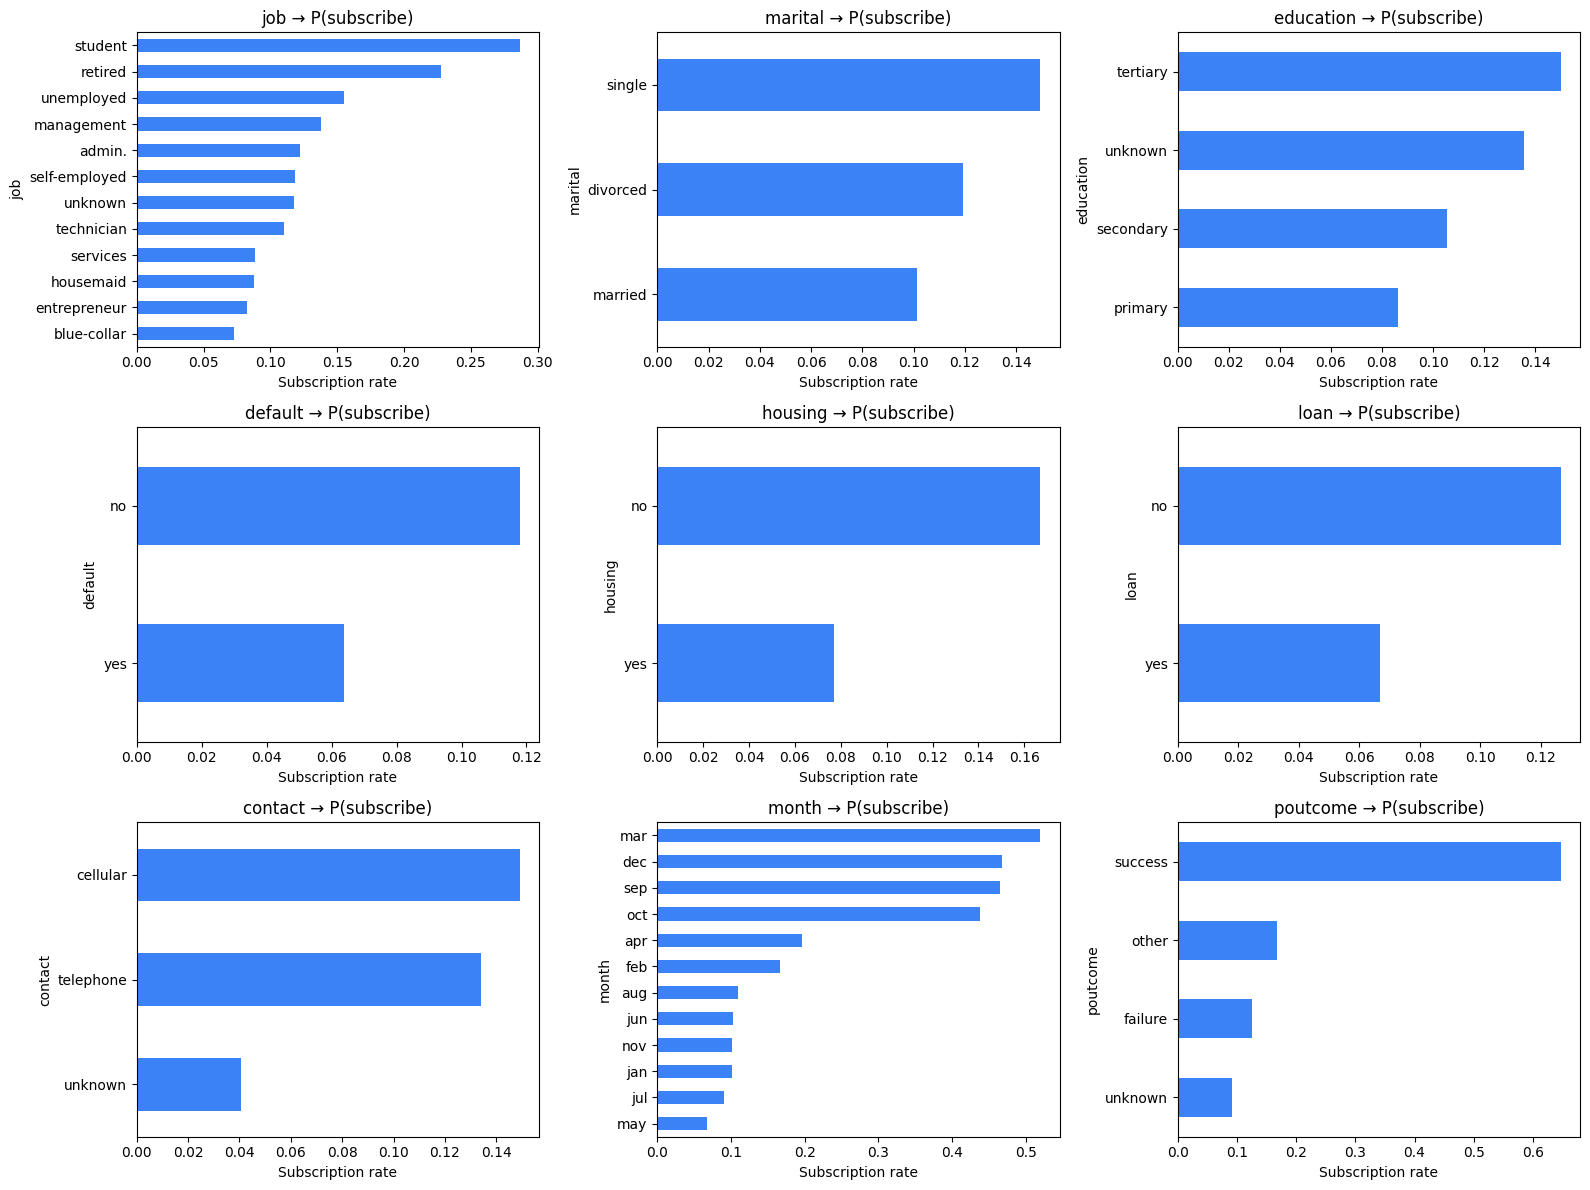

In [7]:
# Categorical columns vs target
cat_cols = ['job', 'marital', 'education', 'default', 'housing',
            'loan', 'contact', 'month', 'poutcome']
fig, axes = plt.subplots(3, 3, figsize=(16, 12))
for ax, col in zip(axes.flat, cat_cols):
    pct = pd.crosstab(df[col], df['y'], normalize='index')['yes']
    pct.sort_values().plot(kind='barh', color='#3b82f6', ax=ax)
    ax.set_title(f'{col} → P(subscribe)')
    ax.set_xlabel('Subscription rate')
plt.tight_layout()
plt.show()

**Notable patterns:**
- Customers who were successful in previous campaigns (`poutcome=success`) subscribe at much higher rates.
- Students and retirees subscribe more than blue-collar workers.
- Cellular contact has a higher conversion rate than telephone.
- `duration` is highly predictive but is a leak signal in production (call duration is unknown before the call). We keep it for assignment fidelity but flag the caveat.

## 4. Preprocessing pipeline

Wrap `ColumnTransformer` to scale numerics + one-hot encode categoricals so the entire pipeline can be saved and used for inference.

In [8]:
X = df.drop(columns=['y'])
y = (df['y'] == 'yes').astype(int)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)
print(f'Train: {X_train.shape},  Test: {X_test.shape}')
print(f'Train class balance: {y_train.mean():.3f}')
print(f'Test class balance:  {y_test.mean():.3f}')

Train: (36168, 16),  Test: (9043, 16)
Train class balance: 0.117
Test class balance:  0.117


In [9]:
preprocessor = ColumnTransformer([
    ('num', StandardScaler(), numeric_cols),
    ('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols),
])

## 5. Train Logistic Regression

`class_weight='balanced'` re-weights the loss so minority class has more influence. This trades some precision for much higher recall — the right trade-off for marketing where missing a real subscriber is more costly than calling someone who won't convert.

In [10]:
pipe = Pipeline([
    ('preprocess', preprocessor),
    ('clf', LogisticRegression(
        class_weight='balanced',
        max_iter=1000,
        random_state=RANDOM_STATE,
    )),
])
pipe.fit(X_train, y_train)

Pipeline(steps=[('preprocess',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['age', 'balance', 'duration',
                                                   'campaign', 'pdays',
                                                   'previous']),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['job', 'marital',
                                                   'education', 'default',
                                                   'housing', 'loan', 'contact',
                                                   'month', 'poutcome'])])),
                ('clf',
                 LogisticRegression(class_weight='balanced', max_iter=1000,
                                    random_state=42))])

## 6. Evaluate

In [11]:
y_pred = pipe.predict(X_test)
y_proba = pipe.predict_proba(X_test)[:, 1]

accuracy = float(accuracy_score(y_test, y_pred))
precision = float(precision_score(y_test, y_pred))
recall = float(recall_score(y_test, y_pred))
f1 = float(f1_score(y_test, y_pred))
cm = confusion_matrix(y_test, y_pred)

print(f'Accuracy:  {accuracy:.4f}')
print(f'Precision: {precision:.4f}')
print(f'Recall:    {recall:.4f}')
print(f'F1:        {f1:.4f}')
print()
print(classification_report(y_test, y_pred, target_names=['no', 'yes']))

Accuracy:  0.8462
Precision: 0.4194
Recall:    0.8185
F1:        0.5546

              precision    recall  f1-score   support

          no       0.97      0.85      0.91      7985
         yes       0.42      0.82      0.55      1058

    accuracy                           0.85      9043
   macro avg       0.70      0.83      0.73      9043
weighted avg       0.91      0.85      0.87      9043



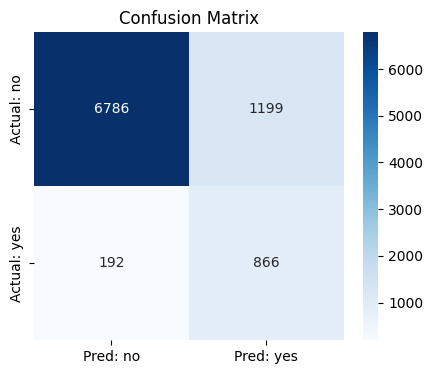

In [12]:
# Confusion matrix heatmap
fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(
    cm, annot=True, fmt='d', cmap='Blues',
    xticklabels=['Pred: no', 'Pred: yes'],
    yticklabels=['Actual: no', 'Actual: yes'],
    ax=ax,
)
ax.set_title('Confusion Matrix')
plt.show()

**Interpretation:** With `class_weight='balanced'`, the model captures the majority of actual subscribers (high recall) at the cost of more false positives (lower precision). For a marketing pipeline where calling extra prospects is cheap but missing a real subscriber is costly, this is the right trade-off.

## 7. Save artifacts

In [13]:
joblib.dump(pipe, OUT_DIR / 'model.joblib')
metrics = {
    'accuracy': accuracy,
    'precision': precision,
    'recall': recall,
    'f1': f1,
    'confusion_matrix': cm.tolist(),
    'n_train': int(len(X_train)),
    'n_test': int(len(X_test)),
    'class_balance_train': float(y_train.mean()),
    'class_balance_test': float(y_test.mean()),
}
(OUT_DIR / 'metrics.json').write_text(json.dumps(metrics, indent=2))
print('Saved:', OUT_DIR / 'model.joblib')
print('Saved:', OUT_DIR / 'metrics.json')

Saved: ../ml/classification/model.joblib
Saved: ../ml/classification/metrics.json


## 8. Inference contract

The deployed SageMaker endpoint expects a JSON payload with the 6 numeric + 9 categorical features:

```json
{
  "age": 35, "job": "admin.", "marital": "married", "education": "secondary",
  "default": "no", "housing": "yes", "loan": "no",
  "contact": "cellular", "month": "may", "poutcome": "unknown",
  "balance": 1500, "duration": 200, "campaign": 1, "pdays": -1, "previous": 0
}
```

Returns: `[{'label': 'yes' | 'no', 'probability': <0..1>}]`.

See `ml/classification/inference.py` for the full SageMaker handler.